<a href="https://colab.research.google.com/github/HAIDER90901/Bank-Management-System/blob/main/AbdullahLaal53.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [90]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [91]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [92]:
#LOading FIle
file_path='/content/drive/MyDrive/gaming_addiction.csv'
df=pd.read_csv('/content/drive/MyDrive/gaming_addiction.csv')
df.head()

,user_id,age,gender,country,occupation,income_level,years_gaming,preferred_genre,platform,device_type,...,absenteeism_days,internet_speed_mbps,screen_time_total_hours,behavioral_cluster,addiction_score,addiction_binary,addiction_severity,burnout_probability,mental_health_risk_score,churn_probability
0,USR000001,21,Male,India,Employed,Middle,9,Sandbox,PC,Laptop,...,7,39.9,5.4,Casual Enjoyer,27.61,0,Mild,1.0,0.920,1.000
1,USR000002,25,Male,India,Employed,Lower-Middle,13,RPG,Mobile,Mixed,...,6,71.5,13.4,Streamer/Creator,55.51,1,Moderate,1.0,0.515,0.813
2,USR000003,26,Male,Brazil,Employed,Middle,14,RPG,PC+Mobile,High-end PC,...,7,119.4,12.3,Streamer/Creator,45.85,0,Moderate,1.0,0.720,0.947
3,USR000004,22,Male,South Korea,Employed,Upper-Middle,10,Strategy,PC+Mobile,Mobile,...,8,136.5,6.9,Toxic Competitor,39.87,0,Mild,1.0,0.520,0.660
4,USR000005,17,Female,India,Student,Middle,5,Strategy,PC,Laptop,...,6,78.8,9.3,Competitive Grinder,46.97,0,Moderate,1.0,0.585,0.867


In [93]:
df.shape

(250, 49)

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 49 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   user_id                      250 non-null    object 
 1   age                          250 non-null    int64  
 2   gender                       250 non-null    object 
 3   country                      250 non-null    object 
 4   occupation                   250 non-null    object 
 5   income_level                 250 non-null    object 
 6   years_gaming                 250 non-null    int64  
 7   preferred_genre              250 non-null    object 
 8   platform                     250 non-null    object 
 9   device_type                  250 non-null    object 
 10  rank_tier                    250 non-null    object 
 11  daily_playtime_hours         250 non-null    float64
 12  weekly_play_sessions         250 non-null    int64  
 13  late_night_sessions_

In [95]:
df.describe()

,age,years_gaming,daily_playtime_hours,weekly_play_sessions,late_night_sessions_hours,weekend_playtime_hours,consecutive_hours_max,multiplayer_ratio,toxic_chat_reports,rage_quit_frequency,...,missed_deadlines,productivity_drop_percent,absenteeism_days,internet_speed_mbps,screen_time_total_hours,addiction_score,addiction_binary,burnout_probability,mental_health_risk_score,churn_probability
count,250.000000,250.000000,250.000000,250.000000,250.0000,250.000000,250.000000,250.000000,250.000000,250.000000,...,250.000000,250.000000,250.00000,250.000000,250.000000,250.00000,250.000000,250.000000,250.000000,250.000000
mean,22.160000,9.668000,6.153200,7.056000,2.1024,8.368400,9.714800,0.462240,2.948000,1.896000,...,2.828000,15.986400,5.52400,99.253200,8.239600,38.74448,0.168000,0.996856,0.509640,0.795556
std,5.455037,5.460866,2.656902,3.517721,1.2007,4.085876,4.828877,0.227391,5.451621,2.353581,...,2.088027,10.581607,3.14212,55.057918,2.894558,11.74977,0.374616,0.043240,0.140448,0.120904
min,13.000000,1.000000,0.500000,1.000000,0.0000,0.500000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,5.000000,1.200000,12.28000,0.000000,0.320000,0.120000,0.150000
25%,18.000000,6.000000,4.225000,4.000000,1.1250,5.600000,5.525000,0.300000,0.000000,0.000000,...,1.000000,8.150000,3.00000,61.375000,6.200000,29.88250,0.000000,1.000000,0.406250,0.732250
50%,22.000000,9.000000,6.450000,7.000000,2.1000,8.150000,10.100000,0.450000,1.000000,1.000000,...,3.000000,15.900000,6.00000,99.150000,8.200000,39.87500,0.000000,1.000000,0.515000,0.808000
75%,27.000000,14.750000,8.175000,10.000000,3.0000,10.850000,13.175000,0.630000,2.000000,3.000000,...,4.000000,22.975000,8.00000,133.575000,10.500000,47.11000,0.000000,1.000000,0.600000,0.878000
max,40.000000,25.000000,11.900000,15.000000,5.2000,20.000000,20.600000,1.000000,32.000000,10.000000,...,8.000000,44.200000,14.00000,255.500000,15.100000,68.00000,1.000000,1.000000,0.920000,1.000000


In [96]:
df.isnull().sum()

,0
user_id,0
age,0
gender,0
country,0
occupation,0
income_level,0
years_gaming,0
preferred_genre,0
platform,0
device_type,0


In [97]:
df.duplicated().sum()

np.int64(0)

In [98]:
df = df.drop_duplicates()

In [99]:
df = df.fillna(df.mean(numeric_only=True))

In [100]:
df = df.dropna()

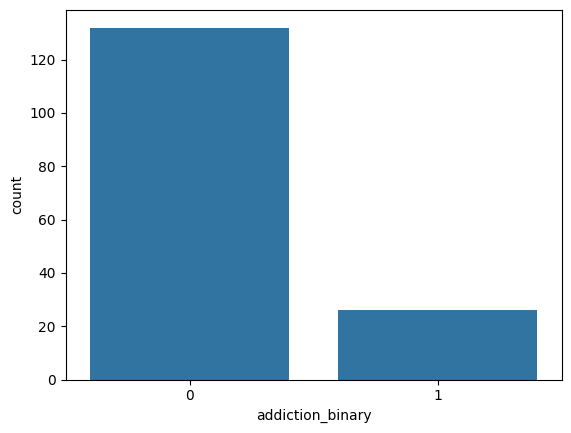

In [101]:
sns.countplot(x="addiction_binary", data=df)
plt.show()

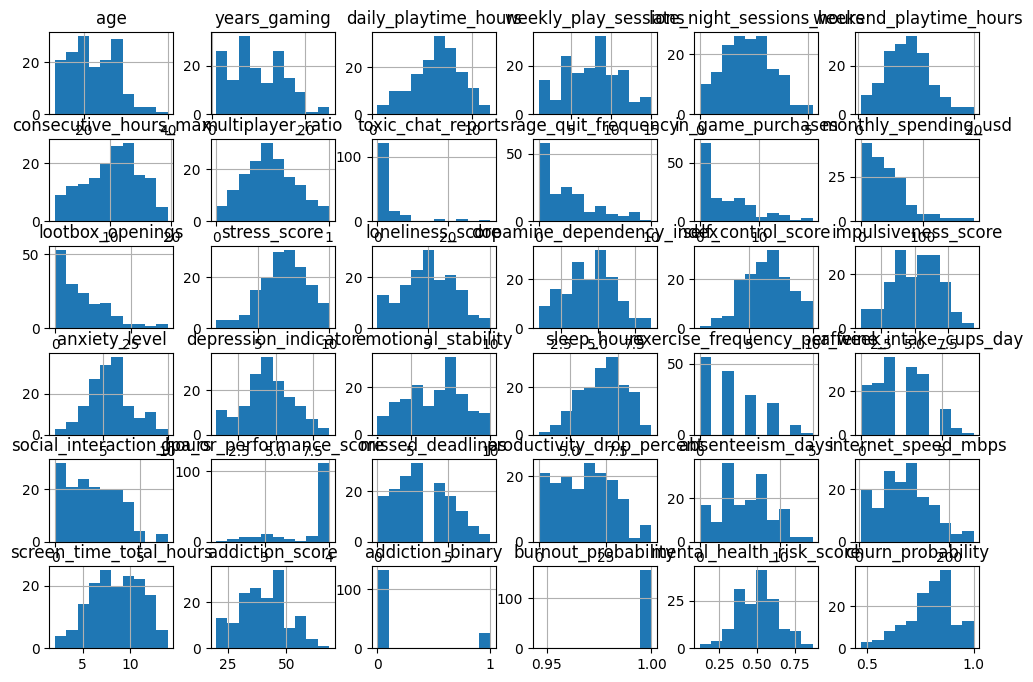

In [102]:
df.hist(figsize=(12,8))
plt.show()

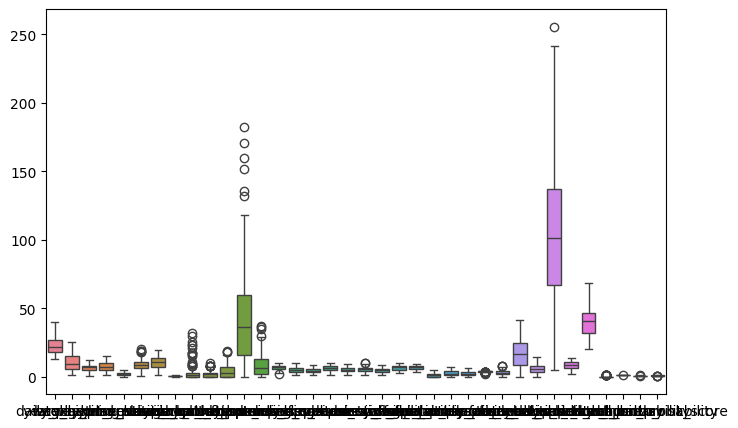

In [103]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df)
plt.show()

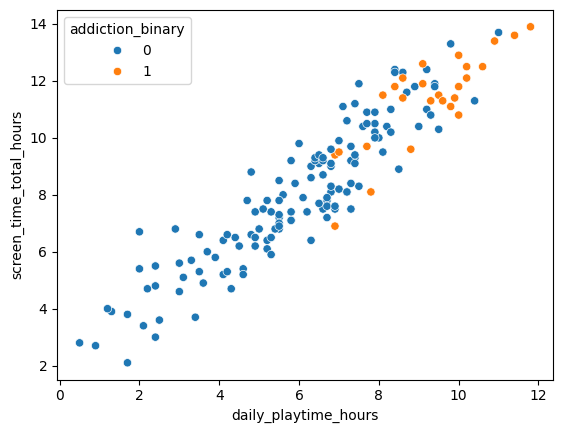

In [104]:
sns.scatterplot(
    x="daily_playtime_hours",
    y="screen_time_total_hours",
    hue="addiction_binary",
    data=df
)

plt.show()

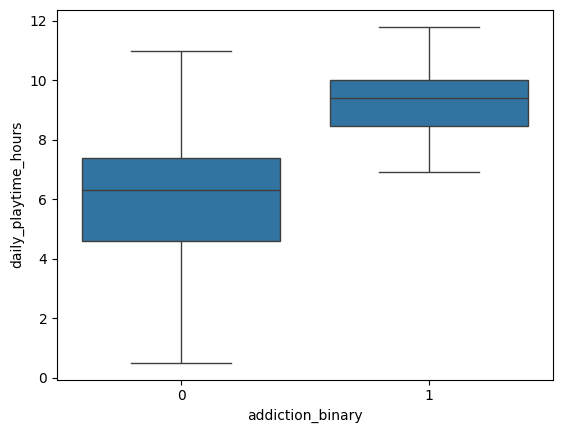

In [105]:
sns.boxplot(
    x="addiction_binary",
    y="daily_playtime_hours",
    data=df
)

plt.show()

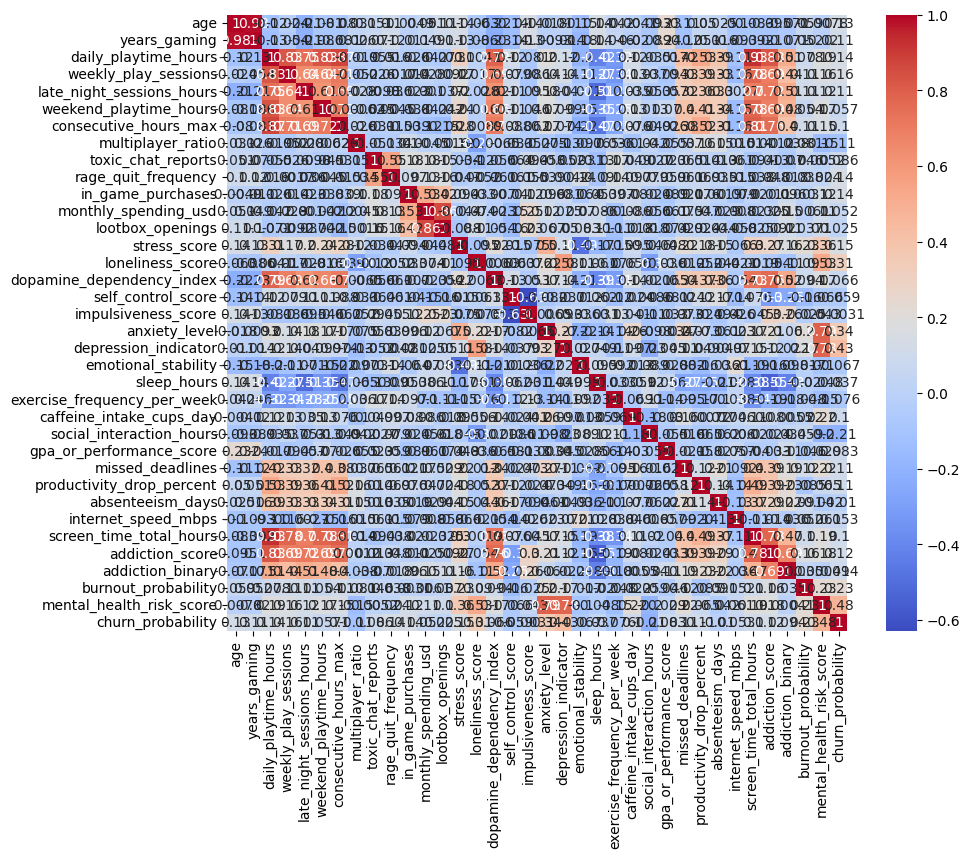

In [106]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()


In [107]:
X = df.drop("addiction_binary", axis=1)
y = df["addiction_binary"]

### Data Splitting

In [108]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (126, 48)
X_test shape: (32, 48)
y_train shape: (126,)
y_test shape: (32,)


### Feature Scaling
Some machine learning algorithms perform better when numerical features are scaled. I'll use `StandardScaler` to standardize the numerical features.

In [109]:
# Identify numerical columns for scaling
numerical_cols = X_train.select_dtypes(include=np.number).columns

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and test data
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Numerical features scaled successfully.")
# Display the first few rows of scaled training data
display(X_train.head())

Numerical features scaled successfully.


,user_id,age,gender,country,occupation,income_level,years_gaming,preferred_genre,platform,device_type,...,productivity_drop_percent,absenteeism_days,internet_speed_mbps,screen_time_total_hours,behavioral_cluster,addiction_score,addiction_severity,burnout_probability,mental_health_risk_score,churn_probability
214,USR000215,-0.355756,Female,UK,Student,Upper-Middle,-0.265557,Sports,PC+Mobile,Laptop,...,-0.101809,0.074735,-1.348896,0.370992,Streamer/Creator,1.482625,Moderate,0.089443,0.508332,-0.054947
83,USR000084,-0.355756,Female,Other,Employed,Middle,-0.265557,MMORPG,PC,High-end PC,...,0.181088,-0.553040,1.184903,0.185349,Social Gamer,-0.438219,Mild,0.089443,-0.200845,-1.633456
193,USR000194,0.142302,Male,Indonesia,Streamer/Content Creator,Low,0.231376,Sports,PC,Mid-range PC,...,-1.096827,-1.808591,-0.477311,-2.413661,Social Gamer,-1.948230,Mild,0.089443,-0.462120,0.231216
137,USR000138,-0.687795,Female,UK,Employed,Lower-Middle,-0.928135,Casual,PC,Mixed,...,-0.882215,-1.808591,0.246140,-0.817126,Escape Seeker,0.461467,Moderate,0.089443,-0.014219,0.692768
242,USR000243,-0.521776,Male,Canada,Employed,Low,-0.596846,MOBA,PC,Console,...,0.951739,-0.239153,1.374378,1.076438,Competitive Grinder,1.493488,Moderate,0.089443,0.023106,0.757386


### Handle Categorical Features
Before training the model, we need to ensure all features are numerical. Since `DecisionTreeClassifier` expects numerical input, I'll drop any remaining non-numerical (object type) columns from `X_train` and `X_test`.

In [110]:
# Identify non-numerical columns
object_cols_train = X_train.select_dtypes(include='object').columns
object_cols_test = X_test.select_dtypes(include='object').columns

# Drop these columns from X_train and X_test
X_train = X_train.drop(columns=object_cols_train)
X_test = X_test.drop(columns=object_cols_test)

print(f"Dropped {len(object_cols_train)} object columns from X_train: {list(object_cols_train)}")
print(f"Dropped {len(object_cols_test)} object columns from X_test: {list(object_cols_test)}")
print("All categorical features handled by dropping.")
display(X_train.head())

Dropped 13 object columns from X_train: ['user_id', 'gender', 'country', 'occupation', 'income_level', 'preferred_genre', 'platform', 'device_type', 'rank_tier', 'subscription_status', 'relationship_status', 'behavioral_cluster', 'addiction_severity']
Dropped 13 object columns from X_test: ['user_id', 'gender', 'country', 'occupation', 'income_level', 'preferred_genre', 'platform', 'device_type', 'rank_tier', 'subscription_status', 'relationship_status', 'behavioral_cluster', 'addiction_severity']
All categorical features handled by dropping.


,age,years_gaming,daily_playtime_hours,weekly_play_sessions,late_night_sessions_hours,weekend_playtime_hours,consecutive_hours_max,multiplayer_ratio,toxic_chat_reports,rage_quit_frequency,...,gpa_or_performance_score,missed_deadlines,productivity_drop_percent,absenteeism_days,internet_speed_mbps,screen_time_total_hours,addiction_score,burnout_probability,mental_health_risk_score,churn_probability
214,-0.355756,-0.265557,0.914523,0.700629,1.141359,1.647877,1.040649,-0.841307,-0.374210,-0.860911,...,-1.087962,-0.003988,-0.101809,0.074735,-1.348896,0.370992,1.482625,0.089443,0.508332,-0.054947
83,-0.355756,-0.265557,-0.012799,0.409278,-0.657406,0.130368,0.456087,0.566224,-0.374210,0.046828,...,0.583141,-1.008994,0.181088,-0.553040,1.184903,0.185349,-0.438219,0.089443,-0.200845,-1.633456
193,0.142302,0.231376,-1.948080,-1.630177,-2.096417,-1.786486,-1.994578,-0.049571,-0.374210,0.500697,...,0.583141,-1.511496,-1.096827,-1.808591,-0.477311,-2.413661,-1.948230,0.089443,-0.462120,0.231216
137,-0.687795,-0.928135,-0.093436,0.700629,0.421853,-0.881305,0.815818,-1.501088,-0.583768,-0.860911,...,0.583141,-0.003988,-0.882215,-1.808591,0.246140,-0.817126,0.461467,0.089443,-0.014219,0.692768
242,-0.521776,-0.596846,0.632294,0.700629,0.152038,-0.481960,0.028907,-0.137542,0.044905,0.954566,...,0.583141,-0.506491,0.951739,-0.239153,1.374378,1.076438,1.493488,0.089443,0.023106,0.757386


### Handle Categorical Features
Before training the model, we need to ensure all features are numerical. Since `DecisionTreeClassifier` expects numerical input, I'll drop any remaining non-numerical (object type) columns from `X_train` and `X_test`.

In [111]:
# Identify non-numerical columns
object_cols_train = X_train.select_dtypes(include='object').columns
object_cols_test = X_test.select_dtypes(include='object').columns

# Drop these columns from X_train and X_test
X_train = X_train.drop(columns=object_cols_train)
X_test = X_test.drop(columns=object_cols_test)

print(f"Dropped {len(object_cols_train)} object columns from X_train: {list(object_cols_train)}")
print(f"Dropped {len(object_cols_test)} object columns from X_test: {list(object_cols_test)}")
print("All categorical features handled by dropping.")
display(X_train.head())

Dropped 0 object columns from X_train: []
Dropped 0 object columns from X_test: []
All categorical features handled by dropping.


,age,years_gaming,daily_playtime_hours,weekly_play_sessions,late_night_sessions_hours,weekend_playtime_hours,consecutive_hours_max,multiplayer_ratio,toxic_chat_reports,rage_quit_frequency,...,gpa_or_performance_score,missed_deadlines,productivity_drop_percent,absenteeism_days,internet_speed_mbps,screen_time_total_hours,addiction_score,burnout_probability,mental_health_risk_score,churn_probability
214,-0.355756,-0.265557,0.914523,0.700629,1.141359,1.647877,1.040649,-0.841307,-0.374210,-0.860911,...,-1.087962,-0.003988,-0.101809,0.074735,-1.348896,0.370992,1.482625,0.089443,0.508332,-0.054947
83,-0.355756,-0.265557,-0.012799,0.409278,-0.657406,0.130368,0.456087,0.566224,-0.374210,0.046828,...,0.583141,-1.008994,0.181088,-0.553040,1.184903,0.185349,-0.438219,0.089443,-0.200845,-1.633456
193,0.142302,0.231376,-1.948080,-1.630177,-2.096417,-1.786486,-1.994578,-0.049571,-0.374210,0.500697,...,0.583141,-1.511496,-1.096827,-1.808591,-0.477311,-2.413661,-1.948230,0.089443,-0.462120,0.231216
137,-0.687795,-0.928135,-0.093436,0.700629,0.421853,-0.881305,0.815818,-1.501088,-0.583768,-0.860911,...,0.583141,-0.003988,-0.882215,-1.808591,0.246140,-0.817126,0.461467,0.089443,-0.014219,0.692768
242,-0.521776,-0.596846,0.632294,0.700629,0.152038,-0.481960,0.028907,-0.137542,0.044905,0.954566,...,0.583141,-0.506491,0.951739,-0.239153,1.374378,1.076438,1.493488,0.089443,0.023106,0.757386


### Model Training: Decision Tree Classifier

In [112]:
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully.")

Decision Tree Classifier trained successfully.


### Model Evaluation

In [113]:
y_pred = dt_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 1.00

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00         6

    accuracy                           1.00        32
   macro avg       1.00      1.00      1.00        32
weighted avg       1.00      1.00      1.00        32


Confusion Matrix:
[[26  0]
 [ 0  6]]


### Decision Tree Visualization
Let's visualize the Decision Tree to understand the rules it learned, which led to the perfect accuracy. This can sometimes reveal if the model is overfitting or if there's a simple, clear separation in the data.

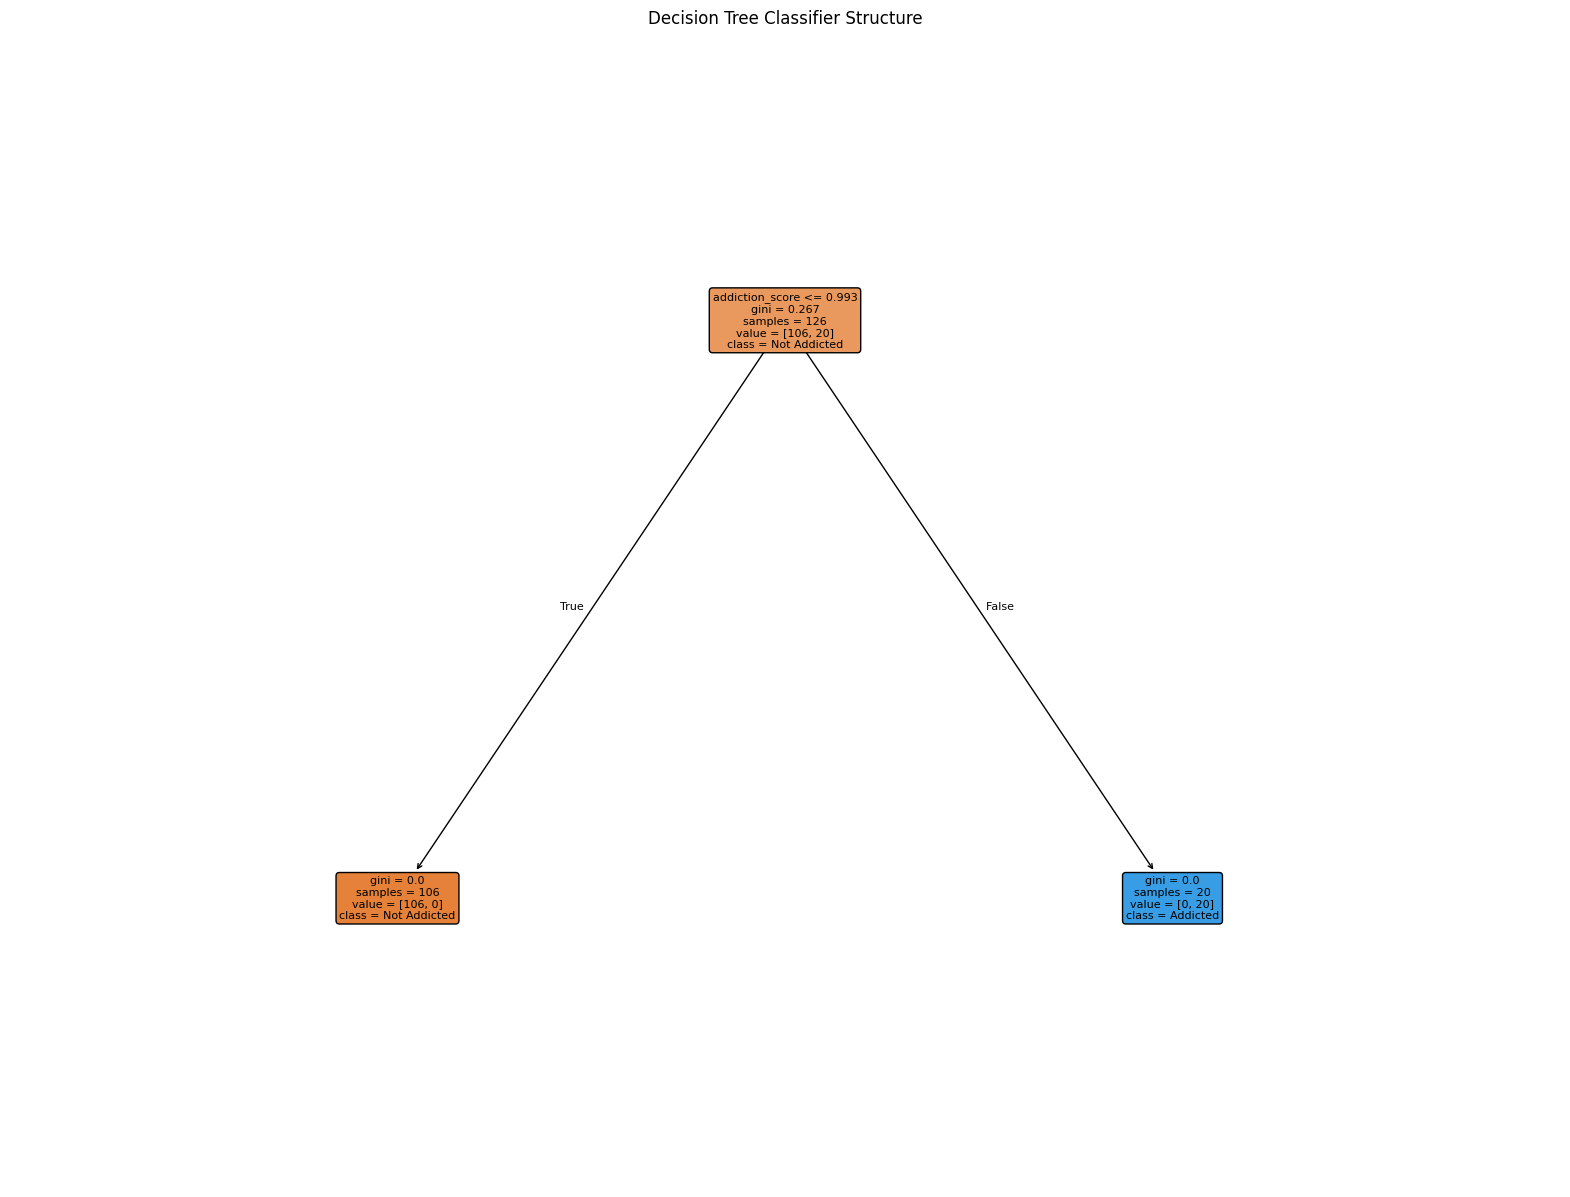

In [114]:
plt.figure(figsize=(20, 15)) # Adjust figure size for better readability

# Get feature names from X_train
feature_names = X_train.columns.tolist()

# Get class names from y (assuming 0 and 1 are the classes)
class_names = ['Not Addicted', 'Addicted']

plot_tree(dt_classifier,
          filled=True,
          feature_names=feature_names,
          class_names=class_names,
          rounded=True,
          fontsize=8)

plt.title('Decision Tree Classifier Structure')
plt.show()

In [115]:
# scaler = StandardScaler()

# X = scaler.fit_transform(X)
# This cell was attempting to scale the entire X DataFrame, which contains non-numerical columns.
# Feature scaling for numerical columns is already correctly handled in cell 'c33a2f69'
# after the train-test split on X_train and X_test.

In [116]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [117]:
# Identify non-numerical columns in X_train and X_test that need to be dropped.
# These typically include identifier columns like 'user_id' and other categorical features.
object_cols_to_drop_train = X_train.select_dtypes(include='object').columns
object_cols_to_drop_test = X_test.select_dtypes(include='object').columns

# Create copies to avoid modifying the original X_train, X_test directly (if needed elsewhere)
# and then drop these columns. The 'errors="ignore"' ensures it doesn't fail if a column is already gone.
X_train_processed = X_train.drop(columns=object_cols_to_drop_train, errors='ignore')
X_test_processed = X_test.drop(columns=object_cols_to_drop_test, errors='ignore')

# Identify numerical columns for scaling on the *processed* data.
# This ensures we only try to scale columns that are indeed numbers.
numerical_cols_train = X_train_processed.select_dtypes(include=np.number).columns
numerical_cols_test = X_test_processed.select_dtypes(include=np.number).columns

# Initialize StandardScaler. Re-initialize here to ensure it's fresh for the current X_train_processed
# especially if X_train was redefined by a previous cell execution.
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data.
# We use .loc to avoid SettingWithCopyWarning and ensure assignment is to the DataFrame slice.
X_train_processed.loc[:, numerical_cols_train] = scaler.fit_transform(X_train_processed[numerical_cols_train])
X_test_processed.loc[:, numerical_cols_test] = scaler.transform(X_test_processed[numerical_cols_test])

# Train Decision Tree
model = DecisionTreeClassifier(random_state=42)

# Fit the model with the fully preprocessed (numeric and scaled) data
model.fit(X_train_processed, y_train)

print("Decision Tree model trained successfully with preprocessed data.")

Decision Tree model trained successfully with preprocessed data.


/tmp/ipykernel_1444/209063472.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.35575624 -0.35575624  0.14230249 -0.68779539 -0.52177581 -1.3518737
  1.13841996  1.30443953  1.13841996  0.97240038  0.8063808   0.97240038
  0.30832207 -1.3518737   0.8063808   0.8063808   0.47434165 -0.02371708
 -1.51789328  0.97240038 -1.51789328  0.8063808  -0.52177581  1.30443953
 -0.52177581 -0.68779539  1.13841996  0.8063808  -0.02371708 -1.51789328
 -1.51789328 -0.02371708  0.8063808   1.63647869  0.14230249  0.47434165
  0.97240038  0.64036123 -0.52177581 -0.02371708 -1.51789328 -0.85381497
  0.47434165  0.8063808   1.47045911 -0.85381497 -0.02371708 -0.35575624
  1.13841996  0.64036123 -0.52177581 -0.18973666  1.30443953  2.96463531
  0.30832207  0.8063808   1.63647869  0.8063808  -0.85381497 -1.01983455
 -1.01983455 -1.3518737   1.13841996 -1.01983455 -1.51789328  0.30832207
 -0.18973666 -1.01983455  0.30832207 -1.185

In [118]:
y_pred = model.predict(X_test_processed)

# Step 18: Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [119]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00         6

    accuracy                           1.00        32
   macro avg       1.00      1.00      1.00        32
weighted avg       1.00      1.00      1.00        32



<Axes: >

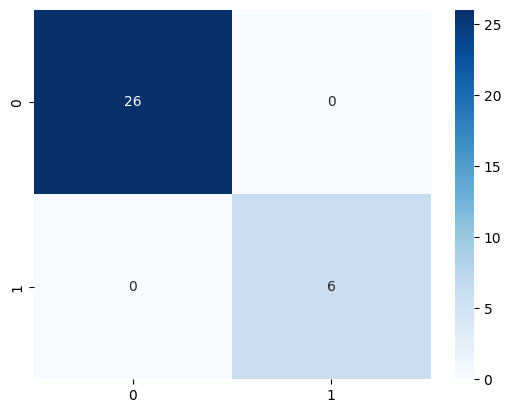

In [120]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

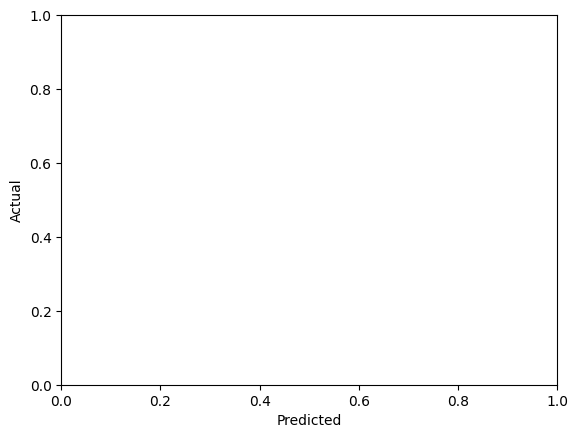

In [121]:
plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

                        Feature  Importance
31              addiction_score         1.0
1                  years_gaming         0.0
0                           age         0.0
2          daily_playtime_hours         0.0
3          weekly_play_sessions         0.0
5        weekend_playtime_hours         0.0
4     late_night_sessions_hours         0.0
7             multiplayer_ratio         0.0
8            toxic_chat_reports         0.0
9           rage_quit_frequency         0.0
6         consecutive_hours_max         0.0
11         monthly_spending_usd         0.0
12             lootbox_openings         0.0
13                 stress_score         0.0
14             loneliness_score         0.0
15    dopamine_dependency_index         0.0
16           self_control_score         0.0
17          impulsiveness_score         0.0
10            in_game_purchases         0.0
18                anxiety_level         0.0
19         depression_indicator         0.0
21                  sleep_hours 

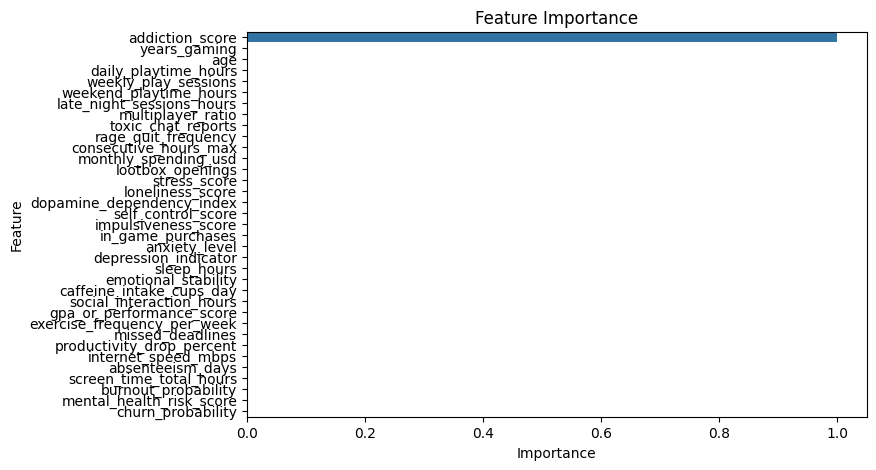

In [122]:
importance = pd.DataFrame({
    "Feature": X_train_processed.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

# Feature Importance Graph

plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")

plt.show()